In [ ]:
%load_ext autoreload 
%autoreload 2
import sys
import os
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix


# Autoreload needs to be used, so that the Jupyter loads the changes in the utility modules
# https://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython  

# Adding utils folder to the path, otherwise Jupyter does not find it
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

# Custom utility functions. Check utils folder for more information
from utils.dataloader import load_data
from utils.standardize import standardize_data
from utils.feature_extract import feature_extract


# Loading training data from the 
X_train, y_train = load_data('training_data')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
/home/santtalainen/PRML_HT/training_data
The data has 1000 samples with [0 1 2 3 4 5 6 7 8 9] classes and respectively their counts [100 100 100 100 100 100 100 100 100 100].


Data standardization and feature extraction

In [144]:
X_train = standardize_data(X_data=X_train)

data = feature_extract(X_train, y_train)
data

,sum,mean,median,std,max,min,class
0,-9.814372e-14,-1.022330e-15,0.106428,0.984251,1.842218,-2.210074,0.0
1,-2.643996e-13,-2.592153e-15,0.075004,0.985184,1.672862,-2.564261,0.0
2,-2.415845e-13,-3.660372e-16,-0.097469,0.997725,1.835234,-1.967101,0.0
3,-4.796163e-14,-2.103580e-16,-0.045843,0.993399,2.230422,-1.960569,0.0
4,-1.101341e-13,-7.059880e-16,-0.099944,0.990338,2.270494,-2.018836,0.0
...,...,...,...,...,...,...,...
995,1.136868e-13,6.015177e-16,0.147223,0.992032,1.734681,-1.578555,9.0
996,1.953993e-14,9.721356e-17,0.393444,0.992509,1.655709,-2.786087,9.0
997,-4.607426e-15,-3.745874e-17,0.316373,0.987730,1.770344,-2.514986,9.0
998,2.309264e-14,1.539509e-16,0.179325,0.989949,1.924997,-2.299363,9.0


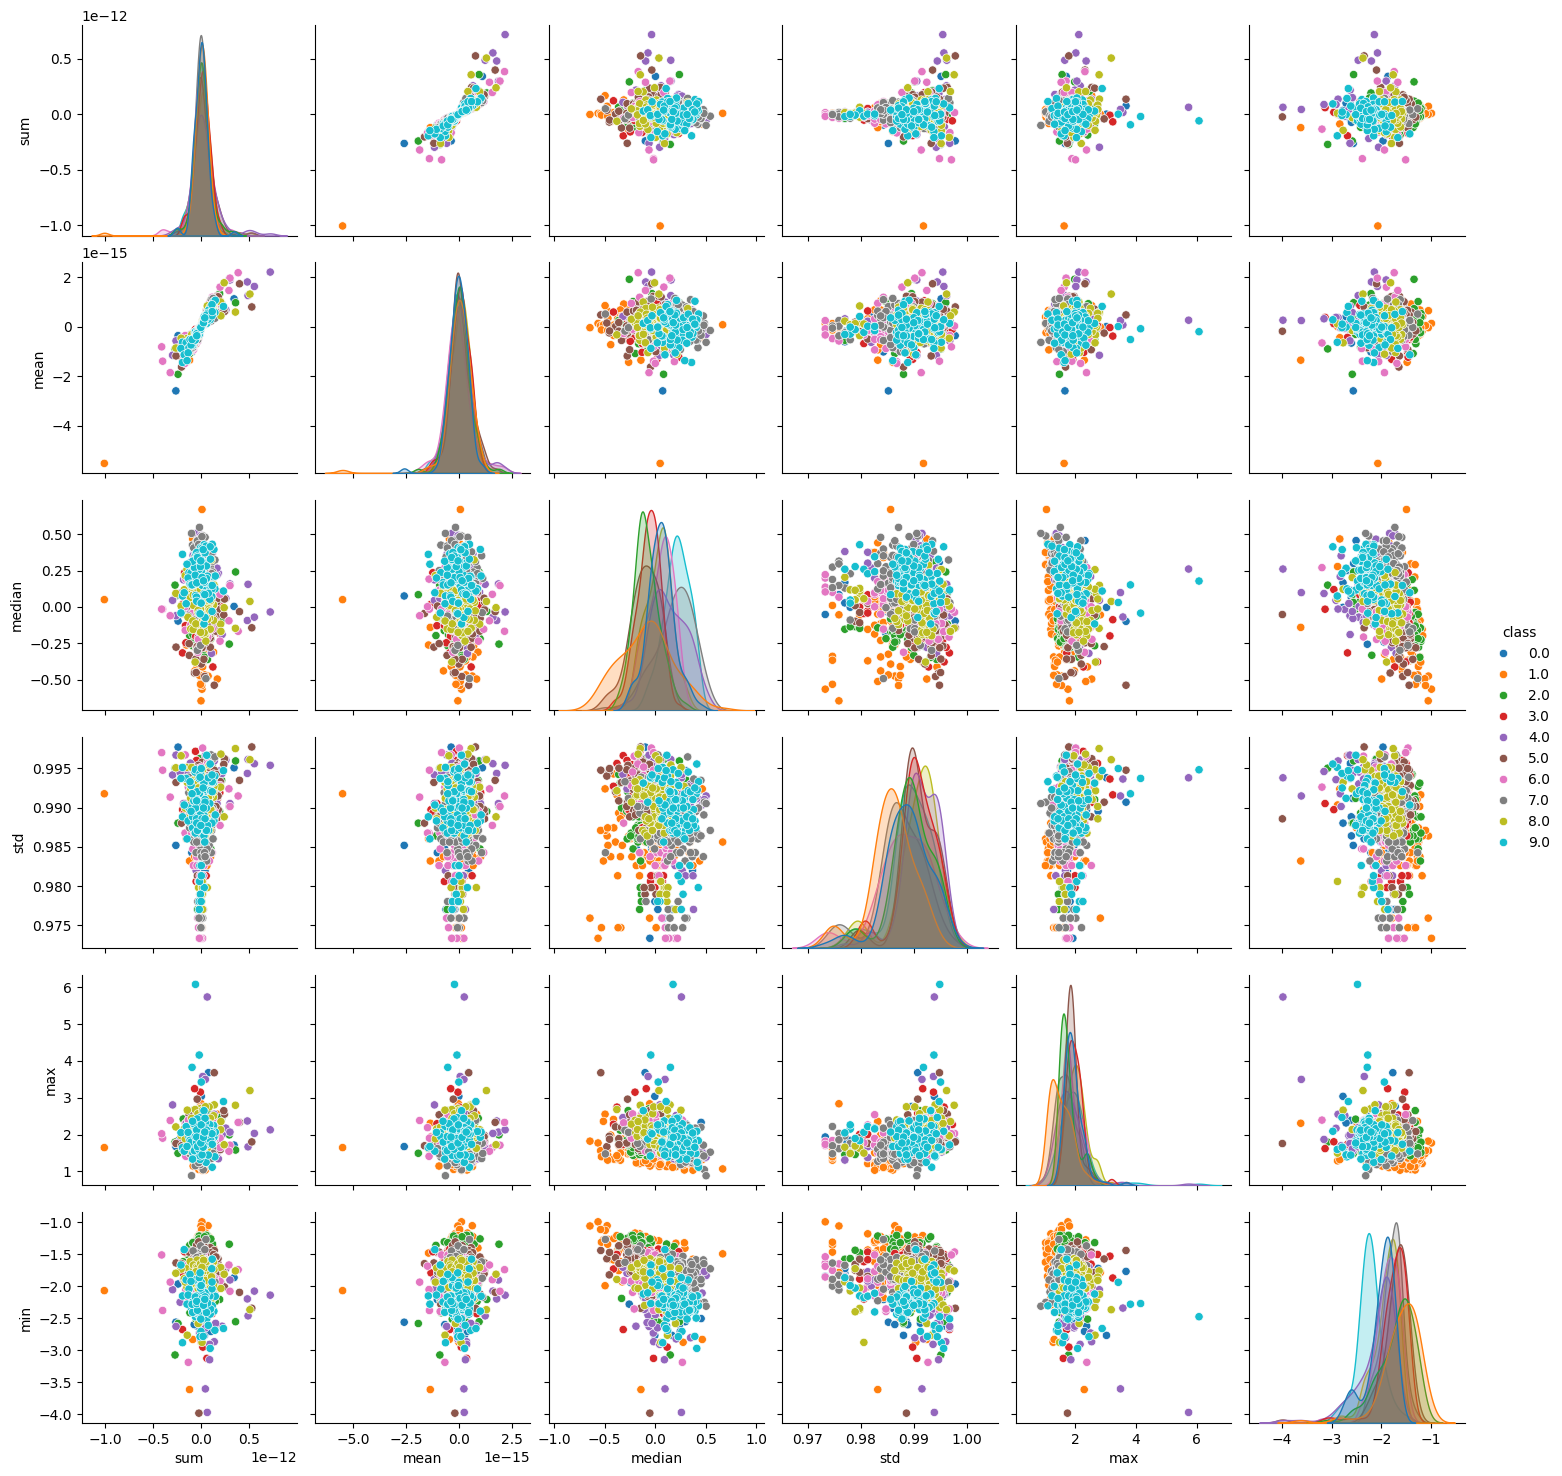

In [ ]:
# https://seaborn.pydata.org/tutorial/color_palettes.html#tools-for-choosing-color-palettes
sns.pairplot(data=data, hue='class', palette='tab10') # Palette needs to be 'tab10', since we have 10 classes. Otherwise sns uses wrong palette, i.e. less classes

Splitting the data into training data and test data, so that we can test the accuracy of the model

In [145]:
y = data['class'].values
X = data.drop('class', axis=1).values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.30, random_state=0, shuffle=True)

#### Bayesian Classifier

In [165]:
class Bayesian_Classifier():

    def __init__(self, regularization = 0):
        self.W = {}
        self.w = {}
        self.w0 = {}
        self.N = None
        self.alpha = regularization

    def fit(self, X_train, y_train):

        self.N = int(np.max(y_train)) + 1 # Checks the highest class of the labels and adds 1 to get the total number of classes


        for i in range(self.N):

            # Computing empirical priors using mean, i.e., P_i = (total number of class i) / (all classes)
            # prior_i = np.mean(y_train == i)

            
            prior_i = .1 # Uniform prior

            # Class i feature samples
            X_i = X_train[y_train == i]
            # print(X_i.shape)

            # Computing the means and covariances of the feature sample X_i
            mean_i = np.mean(X_i, axis=0)
     
            # covi = np.cov(X_i.T) + self.alpha * np.eye(X_i.shape[1])
            covi = np.cov(X_i.T)

            # Computing inverse covariance, prior logarithm and covariance determinant logarithm for decision boundary weights
            covi_inv = np.linalg.inv(covi)
            # print(covi_inv.shape)
            logprior = np.log(prior_i)
            logdet = np.log(np.linalg.det(covi))

            # Weights
            self.W[i] = -0.5 * covi_inv
            self.w[i] = covi_inv @ mean_i
            self.w0[i] = -0.5 * (mean_i.T @ covi_inv @ mean_i + logdet) + logprior

    def predict(self, X_test):

        M = X_test.shape[0] # Sample size
        N = self.N # Total number of classes
        G = np.zeros((M, N)) # Initialize decison surface matrix

        for j in range(M): # each row sample
            x = X_test[j, :]
            for i in range(self.N): # for each class

                # Compute decision sufrace values g_i(x) = x^TW_ix + w_i^Tx + w_i0
                g_i = x.T @ self.W[i] @ x + self.w[i].T @ x + self.w0[i]

                # Save the decision surface value to the matrix in j row for each class i in a column i-1.
                G[j, i-1] = g_i 


         # Technique to get the predictions in scalable way instead of hard coding https://www.kdnuggets.com/2022/07/using-numpy-argmax.html
        predictions = np.argmax(G, axis=1)

        return predictions
    



Testing the model accuracy

In [164]:
BC = Bayesian_Classifier()

BC.fit(X_train, y_train)
predictions = BC.predict(X_test)

accuracy = np.mean(predictions == y_test)

print(f'The accuracy of the model: {accuracy:.4f}.')
print(confusion_matrix(y_test, predictions))

The accuracy of the model: 0.1133.
[[ 0  0  4  5  0  2  6  2  3  5]
 [10  4  0  0  1  0  6  0  0  0]
 [ 4 13  5  2  1  0  3  0  0  5]
 [ 0  0 10  2  4  3  6  1  1  2]
 [ 0  0  1  7  4  2 11  2  3  4]
 [ 1  1  8  0  5  1  6  2  0  4]
 [ 0  0  6  2  0  2 12  1  4  4]
 [ 0  1  1  3  1  0 18  1  7  2]
 [ 0  0  7  0  1  2  7  4  2  3]
 [ 1  0  0  5  1  1  2  2 22  3]]


#### Thoughts
Tested if using different priors would help with the model accuracy, but it seems that the Bayesian classifier still does almost as badly as randomly classifying. Seems like Bayesian classifier can be forgotten and focus should be in logistic regression and neural network implementations. Also, feature extraction is probably going to be the key in achieving good results.